In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from pathlib import Path

MY_DRIVE = Path("/content/drive/MyDrive")

print("Contenu de Mon Drive :")
for p in MY_DRIVE.iterdir():
    print("-", p.name)

Contenu de Mon Drive :
- Texte 8.gdoc
- Fake News Koweït.gslides
- PDC.gdoc
- Golpe de estado del chile.gslides
- plancton.gslides
- Alternateur.gslides
- anglais 
- Créationnisme.gslides
- Proyecto final .gslides
- ES spc Xi Jinping .gdoc
- Capitole.gslides
- Baseball.gdoc
- Génocide Rwandais.gslides
- journée inte
- Inte sup
- Photos topes
- Document (1) (2).pdf
- Document (1) (1).pdf
- Document (1).pdf
- certificat_scolarite_PICAT_Eléonore, Agnès, Françoise.pdf
- certificat_scolarite_PICAT_Eléonore, Agnès, Françoise 2.pdf
- Colab Notebooks
- Document sans titre (2).gdoc
- Document sans titre (1).gdoc
- Tournoi inter-cultures.gform
- Día de los Muertos,.gslides
- Document sans titre.gdoc
- CV.gdoc
- Connaissance des métiers
- Saved from Chrome
- AOP.gslides
- Daft putes moula.gsheet
- Présentation sans titre.gslides
- Exposé SHS.gdoc
- Purge.gdoc
- Notes Projets.gdoc
- Saved from the Google app
- e.vrsprn@gmail.com.gdoc
- Scénario.gdoc
- Chine.gdoc
- data.gsheet
- data

In [ ]:
PROJET_SCIENTIFIQUE = Path("/content/drive/MyDrive/Projet_scientifique")

print("Contenu de Projet_scientifique :")
for p in PROJET_SCIENTIFIQUE.iterdir():
    print("-", p.name)


Contenu de Projet_scientifique :
- projet-nilm


In [ ]:
from pathlib import Path

# Dossier partagé par Adrien : on l'utilise seulement pour LIRE data/ et models/
BASE_DIR = Path("/content/drive/MyDrive/Projet_scientifique/projet-nilm")

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = BASE_DIR / "models"

# Dossier à toi, dans ton Drive personnel : on l'utilise pour ÉCRIRE les résultats
MY_OUTPUT_BASE = Path("/content/drive/MyDrive/projet-nilm-resultats-gabi")
OUTPUTS_DIR = MY_OUTPUT_BASE / "outputs" / "ablation"
MY_MODELS_DIR = MY_OUTPUT_BASE / "models" / "ablation"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MY_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR existe :", BASE_DIR.exists())
print("DATA_DIR existe :", DATA_DIR.exists())
print("PROCESSED_DIR existe :", PROCESSED_DIR.exists())
print("MODELS_DIR existe :", MODELS_DIR.exists())

print("OUTPUTS_DIR existe :", OUTPUTS_DIR.exists())
print("MY_MODELS_DIR existe :", MY_MODELS_DIR.exists())


BASE_DIR existe : True
DATA_DIR existe : True
PROCESSED_DIR existe : True
MODELS_DIR existe : True
OUTPUTS_DIR existe : True
MY_MODELS_DIR existe : True


In [ ]:
print("Contenu de data :")

if DATA_DIR.exists():
    for p in DATA_DIR.iterdir():
        print("-", p.name)
else:
    print("Le dossier data n'existe pas")


Contenu de data :
- processed


In [ ]:
print("Fichiers dans data/processed :")

if PROCESSED_DIR.exists():
    files = list(PROCESSED_DIR.rglob("*"))
    for p in files[:50]:
        if p.is_file():
            print("-", p.relative_to(BASE_DIR))
    print("\nNombre total d'éléments trouvés :", len(files))
else:
    print("Le dossier data/processed n'existe pas")

Fichiers dans data/processed :
- data/processed/norm_params.json
- data/processed/manifest.json
- data/processed/aligned/UK-DALE_house1.pkl
- data/processed/aligned/UK-DALE_house2.pkl
- data/processed/aligned/UK-DALE_house4.pkl
- data/processed/aligned/UK-DALE_house5.pkl
- data/processed/aligned/REDD_house1.pkl
- data/processed/aligned/REDD_house2.pkl
- data/processed/aligned/REDD_house3.pkl
- data/processed/aligned/REDD_house4.pkl
- data/processed/aligned/REDD_house5.pkl
- data/processed/seq2point/fridge__UK-DALE__train.npz
- data/processed/seq2point/dish_washer__UK-DALE__train.npz
- data/processed/seq2point/washing_machine__UK-DALE__train.npz
- data/processed/seq2point/kettle__UK-DALE__train.npz
- data/processed/seq2point/microwave__UK-DALE__train.npz
- data/processed/seq2point/fridge__UK-DALE__test.npz
- data/processed/seq2point/dish_washer__UK-DALE__test.npz
- data/processed/seq2point/washing_machine__UK-DALE__test.npz
- data/processed/seq2point/microwave__UK-DALE__test.npz
- data/

In [ ]:
print("Fichiers modèles .pt :")

if MODELS_DIR.exists():
    pt_files = list(MODELS_DIR.rglob("*.pt"))

    if len(pt_files) == 0:
        print("Aucun fichier .pt trouvé")
    else:
        for p in pt_files:
            print("-", p.relative_to(BASE_DIR))

    print("\nNombre de modèles trouvés :", len(pt_files))
else:
    print("Le dossier models n'existe pas")

Fichiers modèles .pt :
- models/mse/seq2point_fridge_UK-DALE.pt
- models/mse/seq2point_washing_machine_UK-DALE.pt
- models/mse/seq2point_dish_washer_UK-DALE.pt
- models/mse/seq2point_microwave_UK-DALE.pt
- models/mse/seq2point_kettle_UK-DALE.pt
- models/combined/seq2point_fridge_UK-DALE.pt
- models/combined/seq2point_washing_machine_UK-DALE.pt
- models/combined/seq2point_dish_washer_UK-DALE.pt
- models/combined/seq2point_microwave_UK-DALE.pt
- models/combined/seq2point_kettle_UK-DALE.pt

Nombre de modèles trouvés : 10


In [ ]:
RESOLUTIONS = {
    "6s": 599,
    "1min": 60,
    "5min": 12,
    "15min": 4,
    "30min": 2,
}

In [ ]:
npz_files = sorted(PROCESSED_DIR.rglob("*.npz"))

print("Nombre de fichiers .npz :", len(npz_files))

for i, path in enumerate(npz_files[:20]):
    print(f"\n[{i}] {path.relative_to(BASE_DIR)}")
    data = np.load(path, allow_pickle=True)
    print("Clés :", list(data.keys()))

    for key in data.keys():
        arr = data[key]
        if hasattr(arr, "shape"):
            print(f"  - {key}: shape={arr.shape}, dtype={arr.dtype}")
        else:
            print(f"  - {key}: type={type(arr)}")

Nombre de fichiers .npz : 18

[0] data/processed/seq2point/dish_washer__REDD__test.npz
Clés : ['mains', 'target', 'offsets', 'sample_period', 'window_size', 'on_threshold', 'appliance', 'dataset', 'split']
  - mains: shape=(319237,), dtype=float32
  - target: shape=(319237,), dtype=float32
  - offsets: shape=(36,), dtype=int64
  - sample_period: shape=(), dtype=int64
  - window_size: shape=(), dtype=int64
  - on_threshold: shape=(), dtype=int64
  - appliance: shape=(), dtype=<U11
  - dataset: shape=(), dtype=<U4
  - split: shape=(), dtype=<U4

[1] data/processed/seq2point/dish_washer__REDD__train.npz
Clés : ['mains', 'target', 'offsets', 'sample_period', 'window_size', 'on_threshold', 'appliance', 'dataset', 'split']
  - mains: shape=(700786,), dtype=float32
  - target: shape=(700786,), dtype=float32
  - offsets: shape=(66,), dtype=int64
  - sample_period: shape=(), dtype=int64
  - window_size: shape=(), dtype=int64
  - on_threshold: shape=(), dtype=int64
  - appliance: shape=(), dtype

In [ ]:
for path in sorted(PROCESSED_DIR.rglob("*.npz")):
    print(path.relative_to(BASE_DIR))


data/processed/seq2point/dish_washer__REDD__test.npz
data/processed/seq2point/dish_washer__REDD__train.npz
data/processed/seq2point/dish_washer__UK-DALE__test.npz
data/processed/seq2point/dish_washer__UK-DALE__train.npz
data/processed/seq2point/fridge__REDD__test.npz
data/processed/seq2point/fridge__REDD__train.npz
data/processed/seq2point/fridge__UK-DALE__test.npz
data/processed/seq2point/fridge__UK-DALE__train.npz
data/processed/seq2point/kettle__UK-DALE__test.npz
data/processed/seq2point/kettle__UK-DALE__train.npz
data/processed/seq2point/microwave__REDD__test.npz
data/processed/seq2point/microwave__REDD__train.npz
data/processed/seq2point/microwave__UK-DALE__test.npz
data/processed/seq2point/microwave__UK-DALE__train.npz
data/processed/seq2point/washing_machine__REDD__test.npz
data/processed/seq2point/washing_machine__REDD__train.npz
data/processed/seq2point/washing_machine__UK-DALE__test.npz
data/processed/seq2point/washing_machine__UK-DALE__train.npz


In [ ]:
def find_file(appliance, dataset, split):
    """
    Trouve le fichier .npz correspondant à un appareil, un dataset et un split.

    Exemple :
    appliance = "fridge"
    dataset = "UK-DALE"
    split = "train"
    """
    pattern = f"{appliance}__{dataset}__{split}.npz"
    matches = list(PROCESSED_DIR.rglob(pattern))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Aucun fichier trouvé pour {pattern}. "
            f"Vérifie les noms affichés dans la cellule précédente."
        )

    return matches[0]


def load_series(appliance, dataset="UK-DALE"):
    """
    Charge les signaux continus train et test pour un appareil.

    On récupère :
    - mains_train : consommation agrégée de la maison
    - target_train : consommation réelle de l'appareil
    - mains_test
    - target_test
    - sample_period : pas temporel en secondes
    - on_threshold : seuil ON/OFF de l'appareil
    """
    train_path = find_file(appliance, dataset, "train")
    test_path = find_file(appliance, dataset, "test")

    print("Train file :", train_path.relative_to(BASE_DIR))
    print("Test file  :", test_path.relative_to(BASE_DIR))

    train_data = np.load(train_path, allow_pickle=True)
    test_data = np.load(test_path, allow_pickle=True)

    mains_train = train_data["mains"].astype(np.float32)
    target_train = train_data["target"].astype(np.float32)

    mains_test = test_data["mains"].astype(np.float32)
    target_test = test_data["target"].astype(np.float32)

    sample_period = int(train_data["sample_period"])
    on_threshold = float(train_data["on_threshold"])

    print("sample_period :", sample_period, "secondes")
    print("on_threshold  :", on_threshold, "W")
    print("mains_train :", mains_train.shape)
    print("target_train:", target_train.shape)
    print("mains_test  :", mains_test.shape)
    print("target_test :", target_test.shape)

    return {
        "mains_train": mains_train,
        "target_train": target_train,
        "mains_test": mains_test,
        "target_test": target_test,
        "sample_period": sample_period,
        "on_threshold": on_threshold,
        "appliance": appliance,
        "dataset": dataset,
    }

In [ ]:
data_fridge = load_series("fridge", dataset="UK-DALE")

Train file : data/processed/seq2point/fridge__UK-DALE__train.npz
Test file  : data/processed/seq2point/fridge__UK-DALE__test.npz
sample_period : 6 secondes
on_threshold  : 50.0 W
mains_train : (2029323,)
target_train: (2029323,)
mains_test  : (794440,)
target_test : (794440,)


In [ ]:
RESOLUTION_FACTORS = {
    "6s": 1,
    "1min": 10,
    "5min": 50,
    "15min": 150,
    "30min": 300,
}


def downsample_signal(x, factor):
    """
    Dégrade la résolution temporelle d'un signal en moyennant des blocs.

    Si le signal est à 6 secondes :
    - factor = 1   -> 6 s
    - factor = 10  -> 1 min
    - factor = 50  -> 5 min
    - factor = 150 -> 15 min
    - factor = 300 -> 30 min
    """
    x = np.asarray(x, dtype=np.float32)

    n = len(x)
    n_trimmed = (n // factor) * factor

    x = x[:n_trimmed]
    x = x.reshape(-1, factor)

    return x.mean(axis=1)

In [ ]:
def window_size_for_resolution(sample_period, factor):
    """
    Calcule une taille de fenêtre correspondant à environ 1 heure.
    """
    effective_period = sample_period * factor
    window_size = max(2, int(round(3600 / effective_period)))

    return window_size


def make_seq2point_windows(mains, target, window_size, max_windows=None):
    """
    Crée des fenêtres Seq2Point.

    X = fenêtres du signal agrégé mains
    y = valeur de target au centre de chaque fenêtre
    """
    mains = np.asarray(mains, dtype=np.float32)
    target = np.asarray(target, dtype=np.float32)

    n = min(len(mains), len(target))
    mains = mains[:n]
    target = target[:n]

    if n <= window_size:
        raise ValueError(
            f"Signal trop court : n={n}, window_size={window_size}"
        )

    half = window_size // 2

    start_center = half
    end_center = n - (window_size - half)

    centers = np.arange(start_center, end_center)

    if max_windows is not None and len(centers) > max_windows:
        # On prend des centres régulièrement espacés dans le temps
        idx = np.linspace(0, len(centers) - 1, max_windows).astype(int)
        centers = centers[idx]

    X = np.zeros((len(centers), window_size), dtype=np.float32)
    y = np.zeros(len(centers), dtype=np.float32)

    for i, c in enumerate(centers):
        start = c - half
        end = start + window_size

        X[i] = mains[start:end]
        y[i] = target[c]

    return X, y


In [ ]:
def split_train_val(X, y, val_ratio=0.15):
    """
    Découpe chronologiquement train / validation.
    On ne mélange pas les données pour respecter l'ordre temporel.
    """
    n = len(X)
    n_val = int(n * val_ratio)

    X_train = X[:-n_val]
    y_train = y[:-n_val]

    X_val = X[-n_val:]
    y_val = y[-n_val:]

    return X_train, y_train, X_val, y_val


def prepare_data_for_resolution(series_data, resolution_name, max_train_windows=30000, max_test_windows=10000):
    """
    Prépare les données pour une résolution donnée.
    """
    factor = RESOLUTION_FACTORS[resolution_name]
    sample_period = series_data["sample_period"]

    window_size = window_size_for_resolution(sample_period, factor)

    print(f"\nRésolution : {resolution_name}")
    print("factor :", factor)
    print("sample_period effectif :", sample_period * factor, "s")
    print("window_size :", window_size)

    mains_train_ds = downsample_signal(series_data["mains_train"], factor)
    target_train_ds = downsample_signal(series_data["target_train"], factor)

    mains_test_ds = downsample_signal(series_data["mains_test"], factor)
    target_test_ds = downsample_signal(series_data["target_test"], factor)

    X_full_train, y_full_train = make_seq2point_windows(
        mains_train_ds,
        target_train_ds,
        window_size=window_size,
        max_windows=max_train_windows,
    )

    X_test, y_test = make_seq2point_windows(
        mains_test_ds,
        target_test_ds,
        window_size=window_size,
        max_windows=max_test_windows,
    )

    X_train, y_train, X_val, y_val = split_train_val(X_full_train, y_full_train)

    print("X_train :", X_train.shape, "y_train :", y_train.shape)
    print("X_val   :", X_val.shape, "y_val   :", y_val.shape)
    print("X_test  :", X_test.shape, "y_test  :", y_test.shape)

    return X_train, y_train, X_val, y_val, X_test, y_test, window_size

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test, window_size = prepare_data_for_resolution(
    data_fridge,
    resolution_name="1min",
    max_train_windows=5000,
    max_test_windows=2000,
)


Résolution : 1min
factor : 10
sample_period effectif : 60 s
window_size : 60
X_train : (4250, 60) y_train : (4250,)
X_val   : (750, 60) y_val   : (750,)
X_test  : (2000, 60) y_test  : (2000,)


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", DEVICE)

BATCH_SIZE = 256


def make_loaders_from_arrays(X_train, y_train, X_val, y_val, X_test, y_test, on_threshold):
    """
    Normalise les données et crée les DataLoaders PyTorch.
    """
    x_mean = X_train.mean()
    x_std = X_train.std() + 1e-6

    y_mean = y_train.mean()
    y_std = y_train.std() + 1e-6

    X_train_n = (X_train - x_mean) / x_std
    X_val_n = (X_val - x_mean) / x_std
    X_test_n = (X_test - x_mean) / x_std

    y_train_n = (y_train - y_mean) / y_std
    y_val_n = (y_val - y_mean) / y_std
    y_test_n = (y_test - y_mean) / y_std

    st_train = (y_train > on_threshold).astype(np.float32)
    st_val = (y_val > on_threshold).astype(np.float32)
    st_test = (y_test > on_threshold).astype(np.float32)

    def make_dataset(X, y_norm, y_raw, st):
        X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        y_norm_t = torch.tensor(y_norm, dtype=torch.float32).view(-1, 1)
        y_raw_t = torch.tensor(y_raw, dtype=torch.float32).view(-1, 1)
        st_t = torch.tensor(st, dtype=torch.float32).view(-1, 1)

        return TensorDataset(X_t, y_norm_t, y_raw_t, st_t)

    train_ds = make_dataset(X_train_n, y_train_n, y_train, st_train)
    val_ds = make_dataset(X_val_n, y_val_n, y_val, st_val)
    test_ds = make_dataset(X_test_n, y_test_n, y_test, st_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    norm_info = {
        "x_mean": float(x_mean),
        "x_std": float(x_std),
        "y_mean": float(y_mean),
        "y_std": float(y_std),
        "on_threshold": float(on_threshold),
    }

    return train_loader, val_loader, test_loader, norm_info

Device : cuda


In [ ]:
import torch.nn as nn

class Seq2PointAblation(nn.Module):
    def __init__(self, window_size):
        super().__init__()

        kernels = [min(k, window_size) for k in [10, 8, 6, 5, 5]]

        self.features = nn.Sequential(
            nn.Conv1d(1, 30, kernel_size=kernels[0], padding="same"),
            nn.ReLU(),

            nn.Conv1d(30, 30, kernel_size=kernels[1], padding="same"),
            nn.ReLU(),

            nn.Conv1d(30, 40, kernel_size=kernels[2], padding="same"),
            nn.ReLU(),

            nn.Conv1d(40, 50, kernel_size=kernels[3], padding="same"),
            nn.ReLU(),

            nn.Conv1d(50, 50, kernel_size=kernels[4], padding="same"),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, window_size)
            out = self.features(dummy)
            flat_dim = out.reshape(1, -1).shape[1]

        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.power_head = nn.Linear(512, 1)
        self.state_head = nn.Linear(512, 1)

    def forward(self, x):
        z = self.features(x)
        z = self.shared(z)
        power = self.power_head(z)
        state = self.state_head(z)
        return power, state

In [ ]:
mse_fn = nn.MSELoss()
bce_fn = nn.BCEWithLogitsLoss()

LAMBDA_BCE = 0.1
LR = 1e-3
EPOCHS = 8


def compute_loss(pred_power_norm, pred_state_logit, y_norm, y_state):
    loss_mse = mse_fn(pred_power_norm, y_norm)
    loss_bce = bce_fn(pred_state_logit, y_state)
    return loss_mse + LAMBDA_BCE * loss_bce


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    n = 0

    for X, y_norm, y_raw, y_state in loader:
        X = X.to(DEVICE)
        y_norm = y_norm.to(DEVICE)
        y_state = y_state.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        pred_power, pred_state = model(X)
        loss = compute_loss(pred_power, pred_state, y_norm, y_state)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * X.size(0)
        n += X.size(0)

    return total_loss / max(n, 1)


@torch.no_grad()
def predict(model, loader, norm_info):
    model.eval()

    y_true_all = []
    y_pred_all = []

    y_mean = norm_info["y_mean"]
    y_std = norm_info["y_std"]

    for X, y_norm, y_raw, y_state in loader:
        X = X.to(DEVICE)

        pred_norm, pred_state = model(X)
        pred_norm = pred_norm.cpu().numpy().reshape(-1)

        pred_w = pred_norm * y_std + y_mean
        pred_w = np.clip(pred_w, 0, None)

        y_pred_all.append(pred_w)
        y_true_all.append(y_raw.numpy().reshape(-1))

    return np.concatenate(y_true_all), np.concatenate(y_pred_all)


def compute_metrics(y_true, y_pred, on_threshold):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = np.mean(np.abs(y_true - y_pred))

    true_on = y_true > on_threshold
    pred_on = y_pred > on_threshold

    tp = np.sum(true_on & pred_on)
    fp = np.sum(~true_on & pred_on)
    fn = np.sum(true_on & ~pred_on)

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    energy_true = np.sum(y_true)
    energy_pred = np.sum(y_pred)

    energy_error_pct = 100 * abs(energy_pred - energy_true) / (abs(energy_true) + 1e-9)

    return {
        "mae_w": float(mae),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "energy_error_pct": float(energy_error_pct),
        "energy_true": float(energy_true),
        "energy_pred": float(energy_pred),
    }

In [ ]:
train_loader, val_loader, test_loader, norm_info = make_loaders_from_arrays(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    on_threshold=data_fridge["on_threshold"],
)

model = Seq2PointAblation(window_size=window_size).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)
    print(f"Epoch {epoch}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

y_true, y_pred = predict(model, test_loader, norm_info)
metrics = compute_metrics(y_true, y_pred, data_fridge["on_threshold"])

metrics

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv1d(


Epoch 1/8 | train_loss=1.0588 | val_loss=0.9627
Epoch 2/8 | train_loss=0.8504 | val_loss=0.7232
Epoch 3/8 | train_loss=0.7413 | val_loss=0.6397
Epoch 4/8 | train_loss=0.6711 | val_loss=0.5582
Epoch 5/8 | train_loss=0.6035 | val_loss=0.5053
Epoch 6/8 | train_loss=0.5722 | val_loss=0.4966
Epoch 7/8 | train_loss=0.5451 | val_loss=0.4663
Epoch 8/8 | train_loss=0.5391 | val_loss=0.4681


{'mae_w': 36.12928771972656,
 'precision': 0.8691206543949507,
 'recall': 0.5636604774528333,
 'f1': 0.6838294444130172,
 'energy_error_pct': 17.339475631713867,
 'energy_true': 82687.359375,
 'energy_pred': 68349.8046875}

In [ ]:
APPLIANCES = ["fridge", "kettle"]
DATASET = "UK-DALE"

all_results = []

for appliance in APPLIANCES:
    print("\n" + "="*80)
    print("APPAREIL :", appliance)
    print("="*80)

    series_data = load_series(appliance, dataset=DATASET)

    for resolution_name in RESOLUTION_FACTORS.keys():
        print("\n" + "-"*80)
        print("Résolution :", resolution_name)
        print("-"*80)

        X_train, y_train, X_val, y_val, X_test, y_test, window_size = prepare_data_for_resolution(
            series_data,
            resolution_name=resolution_name,
            max_train_windows=80000,
            max_test_windows=20000,
        )

        train_loader, val_loader, test_loader, norm_info = make_loaders_from_arrays(
            X_train, y_train,
            X_val, y_val,
            X_test, y_test,
            on_threshold=series_data["on_threshold"],
        )

        model = Seq2PointAblation(window_size=window_size).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

        for epoch in range(1, EPOCHS + 1):
            train_loss = run_epoch(model, train_loader, optimizer)
            val_loss = run_epoch(model, val_loader, optimizer=None)
            print(f"Epoch {epoch}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        y_true, y_pred = predict(model, test_loader, norm_info)
        metrics = compute_metrics(y_true, y_pred, series_data["on_threshold"])

        result = {
            "appliance": appliance,
            "dataset": DATASET,
            "resolution": resolution_name,
            "window_size": window_size,
            "sample_period_effective_s": series_data["sample_period"] * RESOLUTION_FACTORS[resolution_name],
            "n_train": len(train_loader.dataset),
            "n_val": len(val_loader.dataset),
            "n_test": len(test_loader.dataset),
            **metrics,
        }

        all_results.append(result)

        model_path = MY_MODELS_DIR / f"seq2point_{appliance}_{resolution_name}.pt"

        torch.save({
            "model_state_dict": model.state_dict(),
            "appliance": appliance,
            "dataset": DATASET,
            "resolution": resolution_name,
            "window_size": window_size,
            "norm_info": norm_info,
            "metrics": metrics,
        }, model_path)

        print("Métriques :", metrics)
        print("Modèle sauvegardé :", model_path)


APPAREIL : fridge
Train file : data/processed/seq2point/fridge__UK-DALE__train.npz
Test file  : data/processed/seq2point/fridge__UK-DALE__test.npz
sample_period : 6 secondes
on_threshold  : 50.0 W
mains_train : (2029323,)
target_train: (2029323,)
mains_test  : (794440,)
target_test : (794440,)

--------------------------------------------------------------------------------
Résolution : 6s
--------------------------------------------------------------------------------

Résolution : 6s
factor : 1
sample_period effectif : 6 s
window_size : 600
X_train : (68000, 600) y_train : (68000,)
X_val   : (12000, 600) y_val   : (12000,)
X_test  : (20000, 600) y_test  : (20000,)
Epoch 1/8 | train_loss=0.8233 | val_loss=0.6147
Epoch 2/8 | train_loss=0.6842 | val_loss=0.5746
Epoch 3/8 | train_loss=0.6518 | val_loss=0.5381
Epoch 4/8 | train_loss=0.6200 | val_loss=0.5221
Epoch 5/8 | train_loss=0.5858 | val_loss=0.4914
Epoch 6/8 | train_loss=0.5506 | val_loss=0.4563
Epoch 7/8 | train_loss=0.4950 | val_

In [ ]:
import pandas as pd
import json

results_df = pd.DataFrame(all_results)

display(results_df)

csv_path = OUTPUTS_DIR / "metrics_ablation.csv"
json_path = OUTPUTS_DIR / "metrics_ablation.json"

results_df.to_csv(csv_path, index=False)

with open(json_path, "w") as f:
    json.dump(all_results, f, indent=2)

print("Résultats sauvegardés ici :")
print(csv_path)
print(json_path)

,appliance,dataset,resolution,window_size,sample_period_effective_s,n_train,n_val,n_test,mae_w,precision,recall,f1,energy_error_pct,energy_true,energy_pred
0,fridge,UK-DALE,6s,600,6,68000,12000,20000,28.224623,0.846314,0.784516,0.814244,0.421126,803916.187500,807301.687500
1,fridge,UK-DALE,1min,60,60,68000,12000,20000,20.084923,0.844682,0.858814,0.851689,2.516711,806779.812500,786475.500000
2,fridge,UK-DALE,5min,12,300,34488,6086,15876,24.905033,0.860297,0.778151,0.817165,8.502381,638878.375000,584558.500000
3,fridge,UK-DALE,15min,4,900,11496,2028,5292,28.429045,0.916667,0.532430,0.673607,6.079943,212959.437500,200011.625000
4,fridge,UK-DALE,30min,2,1800,5748,1014,2646,24.704147,0.000000,0.000000,0.000000,7.420199,106479.718750,98578.710938
5,kettle,UK-DALE,6s,600,6,68000,12000,20000,9.695542,0.961538,0.675676,0.793651,30.190598,255211.500000,332261.375000
6,kettle,UK-DALE,1min,60,60,68000,12000,20000,6.804674,0.955556,0.693548,0.803738,8.072186,251005.609375,271267.250000
7,kettle,UK-DALE,5min,12,300,40868,7212,17263,19.268417,0.000000,0.000000,0.000000,65.340858,209316.375000,346085.500000
8,kettle,UK-DALE,15min,4,900,13623,2403,5754,20.964188,0.000000,0.000000,0.000000,56.007473,69771.453125,108848.679688
9,kettle,UK-DALE,30min,2,1800,6812,1201,2877,28.327549,0.000000,0.000000,0.000000,123.280853,34885.730469,77893.156250


Résultats sauvegardés ici :
/content/drive/MyDrive/projet-nilm-resultats-gabi/outputs/ablation/metrics_ablation.csv
/content/drive/MyDrive/projet-nilm-resultats-gabi/outputs/ablation/metrics_ablation.json


In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

resolution_order = ["6s", "1min", "5min", "15min", "30min"]

results_df["resolution"] = pd.Categorical(
    results_df["resolution"],
    categories=resolution_order,
    ordered=True
)

results_df = results_df.sort_values(["appliance", "resolution"])

cols_to_show = [
    "appliance",
    "dataset",
    "resolution",
    "window_size",
    "sample_period_effective_s",
    "n_train",
    "n_val",
    "n_test",
    "mae_w",
    "precision",
    "recall",
    "f1",
    "energy_error_pct",
]

display(results_df[cols_to_show].round(3))

,appliance,dataset,resolution,window_size,sample_period_effective_s,n_train,n_val,n_test,mae_w,precision,recall,f1,energy_error_pct
0,fridge,UK-DALE,6s,600,6,68000,12000,20000,28.225,0.846,0.785,0.814,0.421
1,fridge,UK-DALE,1min,60,60,68000,12000,20000,20.085,0.845,0.859,0.852,2.517
2,fridge,UK-DALE,5min,12,300,34488,6086,15876,24.905,0.860,0.778,0.817,8.502
3,fridge,UK-DALE,15min,4,900,11496,2028,5292,28.429,0.917,0.532,0.674,6.080
4,fridge,UK-DALE,30min,2,1800,5748,1014,2646,24.704,0.000,0.000,0.000,7.420
5,kettle,UK-DALE,6s,600,6,68000,12000,20000,9.696,0.962,0.676,0.794,30.191
6,kettle,UK-DALE,1min,60,60,68000,12000,20000,6.805,0.956,0.694,0.804,8.072
7,kettle,UK-DALE,5min,12,300,40868,7212,17263,19.268,0.000,0.000,0.000,65.341
8,kettle,UK-DALE,15min,4,900,13623,2403,5754,20.964,0.000,0.000,0.000,56.007
9,kettle,UK-DALE,30min,2,1800,6812,1201,2877,28.328,0.000,0.000,0.000,123.281


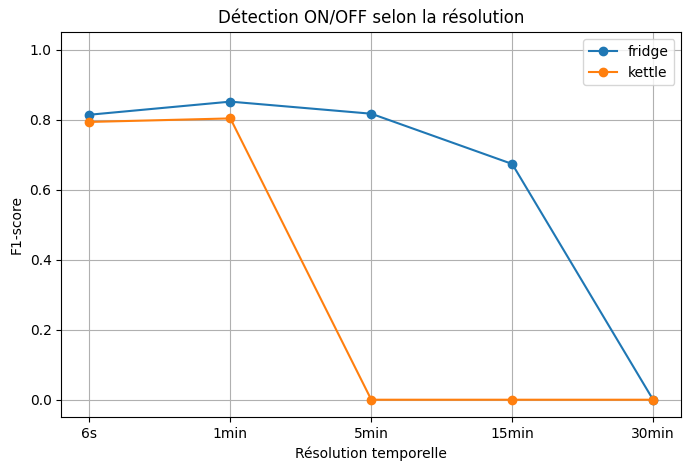

Figure sauvegardée : /content/drive/MyDrive/projet-nilm-resultats-gabi/outputs/ablation/ablation_f1_score.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for appliance in results_df["appliance"].unique():
    sub = results_df[results_df["appliance"] == appliance].sort_values("resolution")
    plt.plot(sub["resolution"].astype(str), sub["f1"], marker="o", label=appliance)

plt.xlabel("Résolution temporelle")
plt.ylabel("F1-score")
plt.title("Détection ON/OFF selon la résolution")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True)

fig_path = OUTPUTS_DIR / "ablation_f1_score.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure sauvegardée :", fig_path)

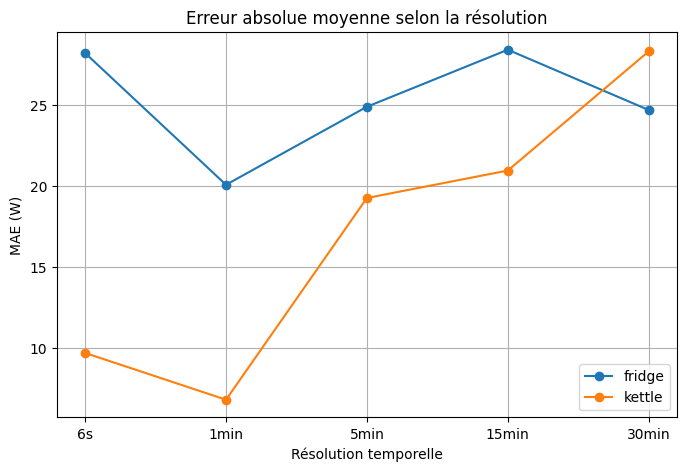

Figure sauvegardée : /content/drive/MyDrive/projet-nilm-resultats-gabi/outputs/ablation/ablation_mae.png


In [ ]:
plt.figure(figsize=(8, 5))

for appliance in results_df["appliance"].unique():
    sub = results_df[results_df["appliance"] == appliance].sort_values("resolution")
    plt.plot(sub["resolution"].astype(str), sub["mae_w"], marker="o", label=appliance)

plt.xlabel("Résolution temporelle")
plt.ylabel("MAE (W)")
plt.title("Erreur absolue moyenne selon la résolution")
plt.legend()
plt.grid(True)

fig_path = OUTPUTS_DIR / "ablation_mae.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure sauvegardée :", fig_path)

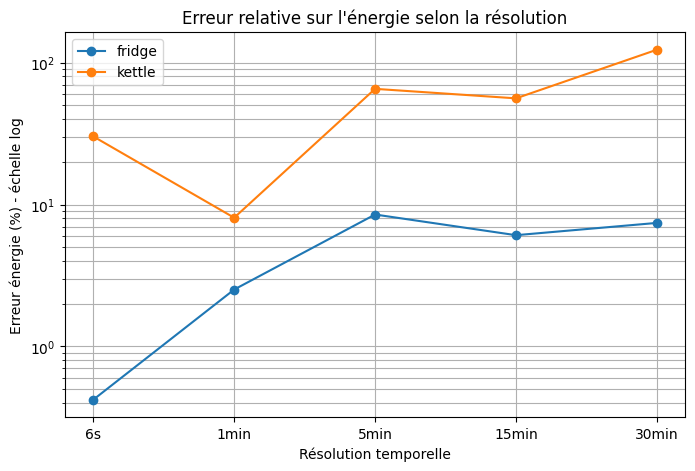

Figure sauvegardée : /content/drive/MyDrive/projet-nilm-resultats-gabi/outputs/ablation/ablation_energy_error_log.png


In [ ]:
plt.figure(figsize=(8, 5))

for appliance in results_df["appliance"].unique():
    sub = results_df[results_df["appliance"] == appliance].sort_values("resolution")
    plt.plot(sub["resolution"].astype(str), sub["energy_error_pct"], marker="o", label=appliance)

plt.xlabel("Résolution temporelle")
plt.ylabel("Erreur énergie (%) - échelle log")
plt.title("Erreur relative sur l'énergie selon la résolution")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both")

fig_path = OUTPUTS_DIR / "ablation_energy_error_log.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure sauvegardée :", fig_path)

## Analyse des résultats

L'étude d'ablation met en évidence un effet net de la résolution temporelle sur les performances du modèle Seq2Point. La dégradation n'affecte pas tous les appareils de la même manière : elle dépend fortement de la durée et de la forme de leur signature électrique.

**Note méthodologique.** Les modèles entraînés ici recalculent leurs paramètres de normalisation à chaque résolution sur leur propre échantillon de train (et utilisent un split train/val chronologique), contrairement au notebook 04 qui utilise les paramètres globaux sauvegardés dans `norm_params.json`. Les valeurs absolues à 6 s ne sont donc pas strictement comparables à celles du notebook 04 ; cette ablation doit être lue comme une étude de *variation relative à travers les résolutions*, sur un protocole autoporté.

**Limite à acter : double effet de la résolution.** À mesure qu'on grossit la maille temporelle, deux choses se dégradent simultanément : l'information disponible par fenêtre (moyennage des signatures) et le volume d'exemples d'entraînement (le signal devient plus court, donc moins de fenêtres possibles malgré le plafond fixé à 80 000). Le tableau le montre clairement : `n_train` chute de 68 000 à 5 748 entre 6 s et 30 min. La perte de performance observée mélange donc ces deux effets ; une étude séparée (rééchantillonner sans réduire le volume) serait nécessaire pour les démêler rigoureusement.

### Fridge

Les performances restent bonnes jusqu'à 5 min : F1 = 0,81 à 6 s, monte même à 0,85 à 1 min, et reste à 0,82 à 5 min. Cette stabilité s'explique par les cycles thermiques d'environ 20 min du réfrigérateur, dont la signature reste visible après moyennage sur quelques minutes.

À 15 min, le F1 chute à 0,67 avec une dissymétrie révélatrice : la précision reste très élevée (0,92) tandis que le recall tombe à 0,53. Autrement dit, le modèle est très sûr de lui *quand* il détecte un ON (peu de faux positifs), mais il manque la moitié des cycles réels. À cette résolution, on sait encore que le frigo tourne, mais on ne sait pas toujours quand.

À 30 min, le F1 tombe à 0,000 — précision et recall nulles — alors que l'erreur énergétique reste à seulement 7,4 %. Ce contraste n'est pas une « approximation de la moyenne globale », mais un comportement précis : **le modèle prédit en permanence une valeur juste en dessous du seuil ON/OFF de 50 W**, ce qui annule la détection (rien ne passe au-dessus du seuil) tout en respectant l'énergie cumulée moyenne (~30-40 W constant). Ce résultat est donc **inexploitable pour piloter quoi que ce soit** : on ne peut pas reporter de charge d'un appareil dont on ne sait pas s'il est allumé, même si on en estime correctement la consommation totale.

### Kettle

Le comportement est beaucoup plus brutal. Le modèle obtient de bons résultats à 6 s et 1 min (F1 = 0,79 et 0,80), puis le F1 tombe à 0,00 dès 5 min, et y reste pour 15 min et 30 min. La signature physique l'explique : le pic de la bouilloire dure 2-3 min à ~2000 W. Moyenné sur 5 min, il devient un plateau de quelques centaines de watts, indistinguable d'autres charges intermédiaires. L'agrégation efface littéralement le signal.

L'erreur énergétique le confirme : 8 % à 1 min, 65 % à 5 min, 123 % à 30 min. Pour le kettle, contrairement au fridge, **dégradation de la détection et dégradation de l'estimation énergétique vont de pair** : on ne sait ni *quand* ni *combien*.

### Lecture croisée des métriques

Ces résultats montrent que les métriques ne mesurent pas la même chose, et qu'**aucune ne suffit isolément** pour juger de l'utilité opérationnelle d'un modèle :
- Le **F1** évalue la capacité à localiser les périodes ON/OFF — indispensable pour piloter du report de charge.
- La **MAE** évalue la justesse instantanée de la puissance — utile pour suivre la consommation en continu.
- L'**erreur énergétique** évalue la justesse cumulée — utile pour la facturation et le suivi global.

Le cas du fridge à 30 min illustre la nécessité de croiser ces trois métriques : une bonne erreur énergétique (7 %) cohabite avec une détection parfaitement nulle (F1 = 0). Dans une perspective de pilotage de flexibilité énergétique, c'est le F1 qui prime ; pour de la facturation par appareil, c'est l'énergie. **Le bon choix dépend de l'usage en aval.**

### Implication pour la question Linky

À résolution Linky standard (30 min), **aucun des deux appareils testés n'est plus détectable** au sens du F1. Le fridge garde une consommation globale estimable mais sans capacité de localisation des cycles. Le kettle disparaît complètement. Cette conclusion conditionne la suite (notebook 08) : la flexibilité énergétique pilotée par compteur Linky standard se heurte à une limite fondamentale, sauf à se contenter d'estimations énergétiques agrégées sans détection fine.

**Caveat important :** cette étude ne porte que sur deux appareils (fridge et kettle), choisis comme cas extrêmes (cycle long vs pic bref). Les appareils intermédiaires et — surtout — *les appareils flexibles* (lave-linge, lave-vaisselle, sèche-linge), qui sont la cible naturelle du report de charge, ne sont pas évalués ici. Une extension à ces appareils est nécessaire pour conclure sur la faisabilité réelle de la flexibilité à résolution Linky.

## Conclusion

Cette étude d’ablation confirme que la résolution temporelle est un facteur déterminant pour la désagrégation de consommation électrique. Les appareils à cycles longs, comme le réfrigérateur, résistent relativement bien à une dégradation modérée de la résolution : leurs performances restent correctes jusqu’à 5 minutes, voire partiellement exploitables à 15 minutes. En revanche, à 30 minutes, la détection fine des états ON/OFF devient impossible.

À l’inverse, les appareils à pics courts, comme la bouilloire, sont très sensibles à l’agrégation temporelle. Le modèle fonctionne encore correctement à 6 secondes et 1 minute, mais échoue dès 5 minutes. Cela montre que les usages courts et ponctuels deviennent rapidement invisibles lorsque la résolution temporelle devient trop grossière.

Dans une perspective proche des données Linky, ces résultats suggèrent que la désagrégation fine appareil par appareil est fortement limitée à une résolution de 30 minutes. Certaines informations globales d’énergie peuvent encore être estimées pour des appareils à cycles longs, mais la détection précise des usages, en particulier courts et intenses, devient très difficile. Cette limite est importante pour discuter les applications possibles du NILM à partir de données de compteurs communicants.

In [ ]:
print("Fichiers sauvegardés dans OUTPUTS_DIR :")

for p in sorted(OUTPUTS_DIR.iterdir()):
    print("-", p.name)

Fichiers sauvegardés dans OUTPUTS_DIR :
- ablation_energy_error.png
- ablation_energy_error_log.png
- ablation_f1_score.png
- ablation_mae.png
- metrics_ablation.csv
- metrics_ablation.json


In [ ]:
# Vérification finale : les fichiers CSV/JSON et PNG ont bien été mis à jour
import os
import time

expected_files = [
    "metrics_ablation.csv",
    "metrics_ablation.json",
    "run_config_ablation.json",
    "ablation_f1_score.png",
    "ablation_mae.png",
    "ablation_energy_error.png",
    "ablation_energy_error_log.png",
]

for filename in expected_files:
    path = OUTPUTS_DIR / filename
    if path.exists():
        print(
            f"OK - {filename} | "
            f"modifié le {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(path)))}"
        )
    else:
        print(f"MANQUANT - {filename}")

OK - metrics_ablation.csv | modifié le 2026-06-04 10:49:23
OK - metrics_ablation.json | modifié le 2026-06-04 10:49:23
OK - run_config_ablation.json | modifié le 2026-06-04 10:59:42
OK - ablation_f1_score.png | modifié le 2026-06-04 10:54:04
OK - ablation_mae.png | modifié le 2026-06-04 10:54:19
OK - ablation_energy_error.png | modifié le 2026-06-04 10:54:56
OK - ablation_energy_error_log.png | modifié le 2026-06-04 10:54:38
